# Doprinos 6 — Analiza uticaja Voice Activity Detection algoritma na Faster-Whisper transkripciju

## Cilj eksperimenta

Cilj eksperimenta je analiza uticaja Voice Activity Detection (VAD) algoritma na brzinu i tačnost Faster-Whisper transkripcije. VAD omogućava detekciju delova audio signala koji sadrže govor, tako da periodi tišine mogu biti izostavljeni iz dalje obrade.

Eksperiment obuhvata dva odvojena podskupa: **5 sintetičkih engleskih snimaka** i **5 prirodnih srpskih snimaka sa kontrolisano dodatim pauzama**. Za svaki snimak direktno se porede režimi `VAD OFF` i `VAD ON`.

Glavne metrike su vreme obrade, Real-Time Factor (RTF) i Word Error Rate (WER). Cilj je utvrditi da li uklanjanje delova bez govora može smanjiti računarski trošak, a da pritom ne dovede do pogoršanja kvaliteta transkripcije.

Engleski i srpski podskup analiziraju se odvojeno, jer se razlikuju i po jeziku i po načinu nastanka audio zapisa.


In [1]:
from pathlib import Path
import time
import wave
import re
import unicodedata
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from faster_whisper import WhisperModel
from jiwer import wer

In [2]:
# ============================================================
# PUTANJE
# ============================================================

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

AUDIO_ROOT = PROJECT_ROOT / "audio"
SR_ORIGINAL_DIR = AUDIO_ROOT / "40Sentences00-08Notebooks"
SR_VAD_DIR = AUDIO_ROOT / "VAD" / "natural_sr"

REZULTATI_DIR = PROJECT_ROOT / "rezultati" / "06_uticaj_vad_filtera"
REZULTATI_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("SR original:", SR_ORIGINAL_DIR)
print("SR VAD:", SR_VAD_DIR)
print("Rezultati:", REZULTATI_DIR)

PROJECT_ROOT: D:\0000000000MasterRad\aleksandar_jovanović_Faster-Whisper&CTranslate2_2026\Projekat2ASR
SR original: D:\0000000000MasterRad\aleksandar_jovanović_Faster-Whisper&CTranslate2_2026\Projekat2ASR\audio\40Sentences00-08Notebooks
SR VAD: D:\0000000000MasterRad\aleksandar_jovanović_Faster-Whisper&CTranslate2_2026\Projekat2ASR\audio\VAD\natural_sr
Rezultati: D:\0000000000MasterRad\aleksandar_jovanović_Faster-Whisper&CTranslate2_2026\Projekat2ASR\rezultati\06_uticaj_vad_filtera


In [3]:
# ============================================================
# PRONALAŽENJE STARIH ENGLESKIH VAD FAJLOVA
# ============================================================

# Skripta prvo proverava novi organizovani folder, zatim stare lokacije.

EN_KANDIDAT_DIRS = [
    AUDIO_ROOT / "VAD" / "synthetic_en",
    AUDIO_ROOT,
    AUDIO_ROOT / "AUDIOseminarski"
]


def pronadji_en_vad_fajl(naziv):
    for folder in EN_KANDIDAT_DIRS:
        putanja = folder / naziv
        if putanja.exists():
            return putanja

    raise FileNotFoundError(
        f"Nije pronađen {naziv}. Proverene lokacije: {EN_KANDIDAT_DIRS}"
    )

In [4]:
# ============================================================
# REFERENTNI TEKSTOVI — SINTETIČKI ENGLESKI VAD SKUP
# ============================================================

reference_en = {
    "govor_p1_VAD.wav": (
        "Artificial intelligence represents a transformative branch of computer science dedicated to the creation of sophisticated systems capable of solving complex problems, making autonomous decisions, learning from vast amounts of data, and accurately understanding natural human speech in real-time environments."
    ),
    "govor_p2_VAD.wav": (
        "Automatic speech recognition technology enables the seamless conversion of spoken audio signals into structured written text, playing a crucial role in modern applications such as voice assistants, automated transcription services, and accessibility tools for individuals with disabilities."
    ),
    "govor_p3_VAD.wav": (
        "Deep learning based neural network models have significantly improved both the overall quality and the processing speed of modern speech recognition systems, allowing them to perform exceptionally well even in noisy environments and across various acoustic conditions."
    ),
    "govor_p4_VAD.wav": (
        "The Whisper model family, originally developed by OpenAI, uses large-scale neural networks trained on diverse multilingual datasets to enable highly accurate speech recognition, translation, and speaker alignment across dozens of different languages and dialects."
    ),
    "govor_p5_VAD.wav": (
        "Faster Whisper is an advanced and highly optimized implementation of the original Whisper architecture, built on the CTranslate2 inference engine to provide dramatic speed improvements and lower memory consumption without sacrificing transcription accuracy."
    )
}

In [5]:
# ============================================================
# REFERENTNI TEKSTOVI — PRIRODNI SRPSKI VAD SKUP
# ============================================================

reference_sr = {
    "28govornik1_VAD.wav": (
        "Whisper postoji u više veličina modela, od veoma malih do znatno većih modela. Manji modeli zahtevaju manje memorije i uglavnom omogućavaju bržu transkripciju, dok veći modeli mogu da pruže veću tačnost u zahtevnijim uslovima. Zbog toga izbor modela predstavlja kompromis između kvaliteta transkripcije i potrebnih računarskih resursa. Taj kompromis je posebno važan kada se sistem izvršava na običnom računaru bez snažne grafičke kartice."
    ),
    "32govornik3_VAD.wav": (
        "Ljudski govor nije potpuno konstantan signal. Neko govori brzo, neko sporije, a pojedini govornici prave veoma duge pauze između rečenica. Razlikuju se i visina glasa, naglasak, način izgovora i jačina govora. Sistem koji postiže odlične rezultate kod jednog govornika zato ne mora nužno da postigne iste rezultate kod druge osobe. Korišćenje više govornika omogućava realniju procenu sposobnosti modela da generalizuje."
    ),
    "33govornik3_VAD.wav": (
        "Voice Activity Detection koristi se za razlikovanje delova zvučnog zapisa u kojima postoji govor od delova u kojima se nalazi tišina. Ako snimak sadrži duge periode bez govora, njihovo uklanjanje može da smanji količinu podataka koju model mora da obradi. Međutim, algoritam mora pažljivo da odredi početak i kraj govora, jer previše agresivno uklanjanje može da odseče deo izgovorene reči i tako negativno utiče na transkripciju."
    ),
    "36govornik1_VAD.wav": (
        "Savremeni sistemi za automatsko prepoznavanje govora imaju veliki broj praktičnih primena. Mogu se koristiti za automatsko pravljenje transkripata sastanaka, generisanje titlova, glasovne asistente, pretragu multimedijalnog sadržaja i poboljšanje pristupačnosti digitalnih sistema. Ipak, kvalitet njihovog rada zavisi od velikog broja faktora. Govornici imaju različite glasove, akcente i brzine govora, dok snimci mogu nastati korišćenjem različitih mikrofona i u različitim prostorijama. Dodatni problem predstavlja pozadinski šum. Sistem koji veoma dobro radi u tihoj prostoriji ne mora da postigne isti rezultat na ulici ili u automobilu. Zbog toga evaluacija sistema ne bi trebalo da bude zasnovana na samo jednom zvučnom zapisu. Potrebno je koristiti više govornika, različite dužine snimaka i različite uslove. Pored tačnosti transkripcije, važno je analizirati vreme izvršavanja, potrošnju memorije i sposobnost sistema da obrađuje zvuk dovoljno brzo za praktičnu primenu."
    ),
    "40govornik3_VAD.wav": (
        "Cilj eksperimentalne analize sistema za automatsko prepoznavanje govora jeste da se utvrdi kako različiti faktori utiču na njegov rad. Možemo menjati veličinu modela, nivo pozadinskog šuma, jezik govornika, parametre dekodiranja, način kvantizacije ili korišćenje algoritma za detekciju govora. Svaki eksperiment treba organizovati tako da možemo jasno da utvrdimo posledice određene promene. Rezultati se zatim mogu posmatrati kroz više metrika. Word Error Rate pokazuje koliko se prepoznati tekst razlikuje od tačnog referentnog transkripta. Latencija pokazuje koliko vremena je potrebno za obradu, dok Real-Time Factor povezuje vreme obrade sa trajanjem samog zvučnog zapisa. Potrošnja memorije je posebno značajna kada model treba da radi na uređajima sa ograničenim resursima. Kombinovanjem ovih rezultata možemo da pronađemo konfiguraciju koja ne mora biti najbolja prema svakoj pojedinačnoj metrici, ali predstavlja dobar kompromis između tačnosti, brzine i potrebnih računarskih resursa."
    )
}

In [6]:
# ============================================================
# FORMIRANJE TEST SKUPA
# ============================================================

test_set = []

# ------------------------------------------------------------
# 5 sintetičkih EN fajlova
# ------------------------------------------------------------

for i in range(1, 6):
    naziv = f"govor_p{i}_VAD.wav"

    test_set.append({
        "audio": pronadji_en_vad_fajl(naziv),
        "original_audio": None,
        "naziv": naziv,
        "jezik": "en",
        "podskup": "synthetic_en",
        "govornik": "gTTS",
        "referenca": reference_en[naziv]
    })

# ------------------------------------------------------------
# 5 prirodnih SR fajlova sa dodatim pauzama
# ------------------------------------------------------------

sr_fajlovi = [
    (28, "govornik1"),
    (32, "govornik3"),
    (33, "govornik3"),
    (36, "govornik1"),
    (40, "govornik3")
]

for broj, govornik in sr_fajlovi:
    naziv_vad = f"{broj}{govornik}_VAD.wav"
    naziv_original = f"{broj}{govornik}.wav"

    test_set.append({
        "audio": SR_VAD_DIR / naziv_vad,
        "original_audio": SR_ORIGINAL_DIR / naziv_original,
        "naziv": naziv_vad,
        "jezik": "sr",
        "podskup": "natural_sr",
        "govornik": govornik,
        "referenca": reference_sr[naziv_vad]
    })


print(f"Definisano ukupno {len(test_set)} VAD test fajlova.")

Definisano ukupno 10 VAD test fajlova.


In [7]:
# ============================================================
# PROVERA FAJLOVA I TRAJANJA
# ============================================================

def trajanje_wav(putanja):
    with wave.open(str(putanja), "rb") as wf:
        return wf.getnframes() / float(wf.getframerate())


provera = []

for item in test_set:
    if not item["audio"].exists():
        raise FileNotFoundError(
            f"Nedostaje VAD fajl: {item['audio']}"
        )

    vad_trajanje = trajanje_wav(item["audio"])

    original_trajanje = np.nan
    dodata_tisina = np.nan
    udeo_tisine = np.nan

    if item["original_audio"] is not None:
        if not item["original_audio"].exists():
            raise FileNotFoundError(
                f"Nedostaje originalni fajl: {item['original_audio']}"
            )

        original_trajanje = trajanje_wav(item["original_audio"])
        dodata_tisina = vad_trajanje - original_trajanje

        if vad_trajanje > 0:
            udeo_tisine = dodata_tisina / vad_trajanje * 100

    item["trajanje_vad"] = vad_trajanje
    item["trajanje_original"] = original_trajanje
    item["dodata_tisina"] = dodata_tisina
    item["udeo_dodate_tisine"] = udeo_tisine

    provera.append({
        "Podskup": item["podskup"],
        "Jezik": item["jezik"],
        "Fajl": item["naziv"],
        "VAD trajanje [s]": round(vad_trajanje, 3),
        "Original trajanje [s]": (
            round(original_trajanje, 3)
            if not np.isnan(original_trajanje)
            else np.nan
        ),
        "Dodata tišina [s]": (
            round(dodata_tisina, 3)
            if not np.isnan(dodata_tisina)
            else np.nan
        ),
        "Udeo dodate tišine [%]": (
            round(udeo_tisine, 2)
            if not np.isnan(udeo_tisine)
            else np.nan
        )
    })


tabela_provera = pd.DataFrame(provera)
display(tabela_provera)

,Podskup,Jezik,Fajl,VAD trajanje [s],Original trajanje [s],Dodata tišina [s],Udeo dodate tišine [%]
0,synthetic_en,en,govor_p1_VAD.wav,34.232,NaN,NaN,NaN
1,synthetic_en,en,govor_p2_VAD.wav,33.152,NaN,NaN,NaN
2,synthetic_en,en,govor_p3_VAD.wav,30.872,NaN,NaN,NaN
3,synthetic_en,en,govor_p4_VAD.wav,33.080,NaN,NaN,NaN
4,synthetic_en,en,govor_p5_VAD.wav,30.512,NaN,NaN,NaN
5,natural_sr,sr,28govornik1_VAD.wav,36.840,30.697,6.143,16.68
6,natural_sr,sr,32govornik3_VAD.wav,34.835,27.968,6.867,19.71
7,natural_sr,sr,33govornik3_VAD.wav,38.370,31.254,7.116,18.55
8,natural_sr,sr,36govornik1_VAD.wav,74.985,69.010,5.975,7.97
9,natural_sr,sr,40govornik3_VAD.wav,88.041,79.772,8.269,9.39


In [8]:
# ============================================================
# NORMALIZACIJA TEKSTA ZA WER
# ============================================================

def normalizuj_tekst(text):
    text = unicodedata.normalize("NFKC", str(text)).lower()

    # Zadržavamo slova i brojeve, a interpunkciju pretvaramo u razmak.
    text = re.sub(r"[^\w\sčćžšđ]", " ", text, flags=re.UNICODE)

    text = re.sub(r"_", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text


def izracunaj_wer(referenca, transkript):
    ref = normalizuj_tekst(referenca)
    hyp = normalizuj_tekst(transkript)

    return wer(ref, hyp) * 100

Metodologija

Koristi se Faster-Whisper base model sa INT8 izvršavanjem na CPU-u. Za sve eksperimente koriste se isti parametri dekodiranja: beam_size=1 i temperature=0.0.

Jedina glavna promenljiva unutar svakog audio zapisa jeste stanje VAD filtera. U režimu VAD ON koristi se Silero VAD sa pragom threshold=0.5 i minimalnim trajanjem tišine od 500 ms.

Svaka konfiguracija izvršava se tri puta, a kao glavno vreme koristi se medijana tri merenja kako bi se smanjio uticaj slučajnih oscilacija vremena izvršavanja. Pre merenja izvršava se warm-up za oba režima.

Kod prirodnog srpskog podskupa kontrolisano je dodato između 5,975 i 8,269 s tišine, odnosno približno 7,97–19,71% ukupnog trajanja snimka. Referentni tekst ostaje isti jer dodavanje tišine ne menja govorni sadržaj.

WER se računa nad istom referencom za VAD OFF i VAD ON, što omogućava direktnu proveru da li VAD menja kvalitet dobijene transkripcije

In [9]:
# ============================================================
# UČITAVANJE MODELA
# ============================================================

MODEL_SIZE = "base"
COMPUTE_TYPE = "int8"
DEVICE = "cpu"

BEAM_SIZE = 1
TEMPERATURE = 0.0

VAD_THRESHOLD = 0.5
MIN_SILENCE_MS = 500

BROJ_PONAVLJANJA = 3
RANDOM_SEED = 42


print("Učitavanje Faster-Whisper base INT8 modela...")

model = WhisperModel(
    MODEL_SIZE,
    device=DEVICE,
    compute_type=COMPUTE_TYPE
)

print("Model je spreman.")

Učitavanje Faster-Whisper base INT8 modela...
Model je spreman.


In [10]:
# ============================================================
# FUNKCIJA ZA JEDNU TRANSKRIPCIJU
# ============================================================

def transkribuj(putanja, jezik, koristi_vad):
    kwargs = {
        "language": jezik,
        "beam_size": BEAM_SIZE,
        "temperature": TEMPERATURE,
        "vad_filter": koristi_vad
    }

    if koristi_vad:
        kwargs["vad_parameters"] = dict(
            threshold=VAD_THRESHOLD,
            min_silence_duration_ms=MIN_SILENCE_MS
        )

    start = time.perf_counter()

    segments, info = model.transcribe(
        str(putanja),
        **kwargs
    )

    tekst = " ".join(
        segment.text.strip()
        for segment in segments
    ).strip()

    vreme = time.perf_counter() - start

    return tekst, vreme

In [11]:
# ============================================================
# WARM-UP — NE ULAZI U REZULTATE
# ============================================================

warmup_item = test_set[0]

print("Warm-up bez VAD-a...")
_ = transkribuj(
    warmup_item["audio"],
    warmup_item["jezik"],
    False
)

print("Warm-up sa VAD-om...")
_ = transkribuj(
    warmup_item["audio"],
    warmup_item["jezik"],
    True
)

print("Warm-up završen.")

Warm-up bez VAD-a...
Warm-up sa VAD-om...
Warm-up završen.


In [12]:
# ============================================================
# GLAVNI VAD EKSPERIMENT
# ============================================================

rezultati = []
rng = random.Random(RANDOM_SEED)


for indeks, item in enumerate(test_set, start=1):

    print("\n" + "=" * 100)
    print(
        f"[{indeks:02d}/{len(test_set)}] {item['naziv']} | "
        f"{item['podskup']} | jezik={item['jezik']} | "
        f"trajanje={item['trajanje_vad']:.2f}s"
    )
    print("=" * 100)

    # Redosled VAD OFF / ON naizmenično menjamo između fajlova
    # da se smanji sistematski uticaj redosleda merenja.
    if indeks % 2 == 1:
        rezimi = [False, True]
    else:
        rezimi = [True, False]

    for koristi_vad in rezimi:

        naziv_rezima = "VAD ON" if koristi_vad else "VAD OFF"

        vremena = []
        transkripti = []

        for ponavljanje in range(1, BROJ_PONAVLJANJA + 1):

            tekst, vreme = transkribuj(
                item["audio"],
                item["jezik"],
                koristi_vad
            )

            vremena.append(vreme)
            transkripti.append(tekst)

            print(
                f"  {naziv_rezima:<7} | "
                f"ponavljanje {ponavljanje}/{BROJ_PONAVLJANJA} | "
                f"{vreme:.3f} s"
            )

        medijana_vremena = float(np.median(vremena))
        prosecno_vreme = float(np.mean(vremena))
        std_vreme = float(np.std(vremena))

        # Dekodiranje je determinističko pri ovim postavkama.
        # Koristimo prvi transkript za WER.
        transkript = transkripti[0]

        wer_proc = izracunaj_wer(
            item["referenca"],
            transkript
        )

        rtf = medijana_vremena / item["trajanje_vad"]

        rezultati.append({
            "Podskup": item["podskup"],
            "Jezik": item["jezik"],
            "Govornik": item["govornik"],
            "Fajl": item["naziv"],
            "Režim": naziv_rezima,
            "VAD uključen": koristi_vad,
            "Trajanje audio [s]": round(item["trajanje_vad"], 3),
            "Original trajanje [s]": (
                round(item["trajanje_original"], 3)
                if not np.isnan(item["trajanje_original"])
                else np.nan
            ),
            "Dodata tišina [s]": (
                round(item["dodata_tisina"], 3)
                if not np.isnan(item["dodata_tisina"])
                else np.nan
            ),
            "Udeo dodate tišine [%]": (
                round(item["udeo_dodate_tisine"], 2)
                if not np.isnan(item["udeo_dodate_tisine"])
                else np.nan
            ),
            "Vreme 1 [s]": round(vremena[0], 3),
            "Vreme 2 [s]": round(vremena[1], 3),
            "Vreme 3 [s]": round(vremena[2], 3),
            "Prosečno vreme [s]": round(prosecno_vreme, 3),
            "Medijana vremena [s]": round(medijana_vremena, 3),
            "Std vremena [s]": round(std_vreme, 3),
            "RTF": round(rtf, 4),
            "WER [%]": round(wer_proc, 2),
            "Referenca": item["referenca"],
            "Transkript": transkript
        })

        print(
            f"  => {naziv_rezima}: "
            f"medijana={medijana_vremena:.3f}s | "
            f"RTF={rtf:.4f} | "
            f"WER={wer_proc:.2f}%"
        )


print("\nEksperiment je završen.")
print(f"Dobijeno je {len(rezultati)} agregiranih rezultata.")


[01/10] govor_p1_VAD.wav | synthetic_en | jezik=en | trajanje=34.23s
  VAD OFF | ponavljanje 1/3 | 2.013 s
  VAD OFF | ponavljanje 2/3 | 1.995 s
  VAD OFF | ponavljanje 3/3 | 1.995 s
  => VAD OFF: medijana=1.995s | RTF=0.0583 | WER=0.00%
  VAD ON  | ponavljanje 1/3 | 1.289 s
  VAD ON  | ponavljanje 2/3 | 1.315 s
  VAD ON  | ponavljanje 3/3 | 1.356 s
  => VAD ON: medijana=1.315s | RTF=0.0384 | WER=0.00%

[02/10] govor_p2_VAD.wav | synthetic_en | jezik=en | trajanje=33.15s
  VAD ON  | ponavljanje 1/3 | 1.380 s
  VAD ON  | ponavljanje 2/3 | 1.267 s
  VAD ON  | ponavljanje 3/3 | 1.295 s
  => VAD ON: medijana=1.295s | RTF=0.0391 | WER=8.11%
  VAD OFF | ponavljanje 1/3 | 1.967 s
  VAD OFF | ponavljanje 2/3 | 2.026 s
  VAD OFF | ponavljanje 3/3 | 1.949 s
  => VAD OFF: medijana=1.967s | RTF=0.0593 | WER=8.11%

[03/10] govor_p3_VAD.wav | synthetic_en | jezik=en | trajanje=30.87s
  VAD OFF | ponavljanje 1/3 | 2.049 s
  VAD OFF | ponavljanje 2/3 | 2.102 s
  VAD OFF | ponavljanje 3/3 | 2.004 s
  

In [13]:
# ============================================================
# DETALJNI REZULTATI
# ============================================================

df = pd.DataFrame(rezultati)

display(
    df[
        [
            "Podskup",
            "Jezik",
            "Fajl",
            "Režim",
            "Trajanje audio [s]",
            "Dodata tišina [s]",
            "Medijana vremena [s]",
            "RTF",
            "WER [%]"
        ]
    ]
)

,Podskup,Jezik,Fajl,Režim,Trajanje audio [s],Dodata tišina [s],Medijana vremena [s],RTF,WER [%]
0,synthetic_en,en,govor_p1_VAD.wav,VAD OFF,34.232,NaN,1.995,0.0583,0.00
1,synthetic_en,en,govor_p1_VAD.wav,VAD ON,34.232,NaN,1.315,0.0384,0.00
2,synthetic_en,en,govor_p2_VAD.wav,VAD ON,33.152,NaN,1.295,0.0391,8.11
3,synthetic_en,en,govor_p2_VAD.wav,VAD OFF,33.152,NaN,1.967,0.0593,8.11
4,synthetic_en,en,govor_p3_VAD.wav,VAD OFF,30.872,NaN,2.049,0.0664,0.00
5,synthetic_en,en,govor_p3_VAD.wav,VAD ON,30.872,NaN,1.948,0.0631,0.00
6,synthetic_en,en,govor_p4_VAD.wav,VAD ON,33.080,NaN,1.982,0.0599,8.57
7,synthetic_en,en,govor_p4_VAD.wav,VAD OFF,33.080,NaN,1.901,0.0575,8.57
8,synthetic_en,en,govor_p5_VAD.wav,VAD OFF,30.512,NaN,1.926,0.0631,21.21
9,synthetic_en,en,govor_p5_VAD.wav,VAD ON,30.512,NaN,1.247,0.0409,15.15


Analiza ukupnih rezultata

Rezultati pokazuju da efekat VAD filtera zavisi od karakteristika testiranog audio skupa i količine tišine koju algoritam može da eliminiše.

Sintetički engleski skup

Kod sintetičkih engleskih snimaka VAD je ostvario jasno ubrzanje. Prosečno vreme obrade smanjeno je sa 1,968 s na 1,557 s, što predstavlja smanjenje od 20,85% i ubrzanje od približno 1,263×.

Prosečan RTF istovremeno je smanjen sa 0,061 na 0,048, što potvrđuje da je količina računarske obrade smanjena kada se VAD koristi.

Prosečan WER nije pogoršan, već je smanjen sa 7,58% na 6,37%, odnosno za 1,21 procentni poen. Corpus WER je takođe smanjen sa 7,14% na 6,04%.

Ipak, poboljšanje nije bilo jednako na svim snimcima. Najveće smanjenje vremena zabeleženo je na pojedinim snimcima sa približno 34–35% kraćim vremenom obrade, dok je kod jednog snimka VAD čak povećao vreme za oko 4,3%.

Zbog malog skupa od pet snimaka rezultat ne treba generalizovati na sav engleski govor, ali pokazuje da u kontrolisanim snimcima sa pauzama VAD može značajno smanjiti vreme obrade bez negativnog uticaja na WER.

Prirodni srpski skup

Kod prirodnih srpskih snimaka efekat na brzinu bio je znatno manji. Prosečno vreme obrade smanjeno je sa 4,302 s na 4,175 s, što predstavlja ubrzanje od samo 1,031×, odnosno smanjenje vremena od 2,96%.

Prosečan RTF promenjen je sa 0,080 na 0,078, pa je i prema ovoj metrici poboljšanje relativno malo.

VAD nije izazvao značajnu promenu prosečne tačnosti. Prosečan WER smanjen je sa 66,28% na 65,80%, odnosno za samo 0,48 procentnih poena, dok se corpus WER promenio sa 62,47% na 62,25%.

Rezultati pojedinačnih snimaka pokazuju da VAD ne garantuje ubrzanje. Na snimku 33govornik3_VAD.wav vreme je smanjeno za 18,73%, a na 40govornik3_VAD.wav za 9,52%. Međutim, na snimcima 28govornik1_VAD.wav, 32govornik3_VAD.wav i 36govornik1_VAD.wav VAD je povećao vreme obrade za približno 5,59%, 2,20% i 5,96%.

To pokazuje da dodatni trošak samog VAD algoritma može umanjiti ili potpuno poništiti korist od uklanjanja tišine kada količina preskočenog audio sadržaja nije dovoljno velika.

In [14]:
# ============================================================
# REZIME PO PODSKUPU I VAD REŽIMU
# ============================================================

rezime = (
    df
    .groupby([
        "Podskup",
        "Jezik",
        "Režim"
    ])
    .agg(
        Broj_snimaka=("Fajl", "count"),
        Prosecno_trajanje=("Trajanje audio [s]", "mean"),
        Prosecno_vreme=("Medijana vremena [s]", "mean"),
        Medijana_vremena=("Medijana vremena [s]", "median"),
        Prosecan_RTF=("RTF", "mean"),
        Medijana_RTF=("RTF", "median"),
        Prosecan_WER=("WER [%]", "mean"),
        Medijana_WER=("WER [%]", "median")
    )
    .reset_index()
    .round(3)
)

print("REZIME PO PODSKUPU I VAD REŽIMU")
display(rezime)

REZIME PO PODSKUPU I VAD REŽIMU


,Podskup,Jezik,Režim,Broj_snimaka,Prosecno_trajanje,Prosecno_vreme,Medijana_vremena,Prosecan_RTF,Medijana_RTF,Prosecan_WER,Medijana_WER
0,natural_sr,sr,VAD OFF,5,54.614,4.302,3.134,0.080,0.082,66.276,68.25
1,natural_sr,sr,VAD ON,5,54.614,4.175,3.174,0.078,0.082,65.796,65.08
2,synthetic_en,en,VAD OFF,5,32.370,1.968,1.967,0.061,0.059,7.578,8.11
3,synthetic_en,en,VAD ON,5,32.370,1.557,1.315,0.048,0.041,6.366,8.11


In [15]:
# ============================================================
# CORPUS WER PO PODSKUPU I REŽIMU
# ============================================================

corpus_redovi = []

for podskup in df["Podskup"].unique():
    for rezim in ["VAD OFF", "VAD ON"]:

        deo = df[
            (df["Podskup"] == podskup) &
            (df["Režim"] == rezim)
        ]

        ref_corpus = " ".join(
            normalizuj_tekst(x)
            for x in deo["Referenca"]
        )

        hyp_corpus = " ".join(
            normalizuj_tekst(x)
            for x in deo["Transkript"]
        )

        corpus_wer = wer(
            ref_corpus,
            hyp_corpus
        ) * 100

        corpus_redovi.append({
            "Podskup": podskup,
            "Režim": rezim,
            "Corpus WER [%]": round(corpus_wer, 2)
        })


tabela_corpus = pd.DataFrame(corpus_redovi)
display(tabela_corpus)

,Podskup,Režim,Corpus WER [%]
0,synthetic_en,VAD OFF,7.14
1,synthetic_en,VAD ON,6.04
2,natural_sr,VAD OFF,62.47
3,natural_sr,VAD ON,62.25


In [16]:
# ============================================================
# DIREKTNO POREĐENJE VAD OFF VS VAD ON PO FAJLU
# ============================================================

off = df[df["Režim"] == "VAD OFF"].copy()
on = df[df["Režim"] == "VAD ON"].copy()

poredjenje = off.merge(
    on,
    on=[
        "Podskup",
        "Jezik",
        "Govornik",
        "Fajl"
    ],
    suffixes=("_OFF", "_ON")
)

poredjenje["Ubrzanje VAD [x]"] = (
    poredjenje["Medijana vremena [s]_OFF"] /
    poredjenje["Medijana vremena [s]_ON"]
)

poredjenje["Promena vremena [%]"] = (
    (
        poredjenje["Medijana vremena [s]_ON"] -
        poredjenje["Medijana vremena [s]_OFF"]
    ) /
    poredjenje["Medijana vremena [s]_OFF"] * 100
)

poredjenje["Smanjenje vremena VAD [%]"] = (
    (
        poredjenje["Medijana vremena [s]_OFF"] -
        poredjenje["Medijana vremena [s]_ON"]
    ) /
    poredjenje["Medijana vremena [s]_OFF"] * 100
)

poredjenje["Promena RTF"] = (
    poredjenje["RTF_ON"] -
    poredjenje["RTF_OFF"]
)

poredjenje["Promena WER [pp]"] = (
    poredjenje["WER [%]_ON"] -
    poredjenje["WER [%]_OFF"]
)

tabela_poredjenje = poredjenje[
    [
        "Podskup",
        "Jezik",
        "Fajl",
        "Trajanje audio [s]_OFF",
        "Dodata tišina [s]_OFF",
        "Medijana vremena [s]_OFF",
        "Medijana vremena [s]_ON",
        "Ubrzanje VAD [x]",
        "Smanjenje vremena VAD [%]",
        "RTF_OFF",
        "RTF_ON",
        "WER [%]_OFF",
        "WER [%]_ON",
        "Promena WER [pp]"
    ]
].copy()

tabela_poredjenje = tabela_poredjenje.round(3)

display(tabela_poredjenje)

,Podskup,Jezik,Fajl,Trajanje audio [s]_OFF,Dodata tišina [s]_OFF,Medijana vremena [s]_OFF,Medijana vremena [s]_ON,Ubrzanje VAD [x],Smanjenje vremena VAD [%],RTF_OFF,RTF_ON,WER [%]_OFF,WER [%]_ON,Promena WER [pp]
0,synthetic_en,en,govor_p1_VAD.wav,34.232,NaN,1.995,1.315,1.517,34.085,0.058,0.038,0.00,0.00,0.00
1,synthetic_en,en,govor_p2_VAD.wav,33.152,NaN,1.967,1.295,1.519,34.164,0.059,0.039,8.11,8.11,0.00
2,synthetic_en,en,govor_p3_VAD.wav,30.872,NaN,2.049,1.948,1.052,4.929,0.066,0.063,0.00,0.00,0.00
3,synthetic_en,en,govor_p4_VAD.wav,33.080,NaN,1.901,1.982,0.959,-4.261,0.058,0.060,8.57,8.57,0.00
4,synthetic_en,en,govor_p5_VAD.wav,30.512,NaN,1.926,1.247,1.545,35.254,0.063,0.041,21.21,15.15,-6.06
5,natural_sr,sr,28govornik1_VAD.wav,36.840,6.143,3.006,3.174,0.947,-5.589,0.082,0.086,68.25,65.08,-3.17
6,natural_sr,sr,32govornik3_VAD.wav,34.835,6.867,3.005,3.071,0.979,-2.196,0.086,0.088,76.67,76.67,0.00
7,natural_sr,sr,33govornik3_VAD.wav,38.370,7.116,3.134,2.547,1.230,18.730,0.082,0.066,78.79,78.79,0.00
8,natural_sr,sr,36govornik1_VAD.wav,74.985,5.975,5.771,6.115,0.944,-5.961,0.077,0.082,56.92,57.69,0.77
9,natural_sr,sr,40govornik3_VAD.wav,88.041,8.269,6.595,5.967,1.105,9.522,0.075,0.068,50.75,50.75,0.00


Uticaj VAD-a na WER

Najvažniji rezultat sa aspekta tačnosti jeste da uključivanje VAD-a u većini testova nije promenilo WER.

Kod engleskog podskupa četiri od pet snimaka imaju isti WER u oba režima. Na govor_p5_VAD.wav WER je smanjen sa 21,21% na 15,15%, odnosno za 6,06 procentnih poena.

Kod srpskog podskupa tri snimka imaju potpuno isti WER. Na 28govornik1_VAD.wav WER je poboljšan sa 68,25% na 65,08%, dok je kod 36govornik1_VAD.wav blago pogoršan sa 56,92% na 57,69%.

Prema tome, u korišćenoj konfiguraciji (threshold=0.5, min_silence_duration_ms=500) nije uočen sistematski negativan uticaj VAD-a na tačnost. Promene WER-a su uglavnom male ili nepostojeće, dok su u pojedinim slučajevima zabeležena i poboljšanja.

In [17]:
# ============================================================
# AGREGATNI EFEKAT VAD-a PO PODSKUPU
# ============================================================

agregatni_redovi = []

for podskup in tabela_poredjenje["Podskup"].unique():

    deo = tabela_poredjenje[
        tabela_poredjenje["Podskup"] == podskup
    ]

    vreme_off = deo["Medijana vremena [s]_OFF"].mean()
    vreme_on = deo["Medijana vremena [s]_ON"].mean()

    rtf_off = deo["RTF_OFF"].mean()
    rtf_on = deo["RTF_ON"].mean()

    wer_off = deo["WER [%]_OFF"].mean()
    wer_on = deo["WER [%]_ON"].mean()

    speedup = vreme_off / vreme_on if vreme_on > 0 else np.nan

    smanjenje_vremena = (
        (vreme_off - vreme_on) / vreme_off * 100
        if vreme_off > 0
        else np.nan
    )

    agregatni_redovi.append({
        "Podskup": podskup,
        "Broj fajlova": len(deo),
        "Prosečno vreme OFF [s]": vreme_off,
        "Prosečno vreme ON [s]": vreme_on,
        "VAD speedup [x]": speedup,
        "Smanjenje vremena [%]": smanjenje_vremena,
        "Prosečan RTF OFF": rtf_off,
        "Prosečan RTF ON": rtf_on,
        "Prosečan WER OFF [%]": wer_off,
        "Prosečan WER ON [%]": wer_on,
        "Promena WER [pp]": wer_on - wer_off
    })


tabela_agregatno = pd.DataFrame(agregatni_redovi).round(3)

print("AGREGATNI EFEKAT VAD FILTERA")
display(tabela_agregatno)

AGREGATNI EFEKAT VAD FILTERA


,Podskup,Broj fajlova,Prosečno vreme OFF [s],Prosečno vreme ON [s],VAD speedup [x],Smanjenje vremena [%],Prosečan RTF OFF,Prosečan RTF ON,Prosečan WER OFF [%],Prosečan WER ON [%],Promena WER [pp]
0,synthetic_en,5,1.968,1.557,1.263,20.848,0.061,0.048,7.578,6.366,-1.212
1,natural_sr,5,4.302,4.175,1.031,2.961,0.080,0.078,66.276,65.796,-0.480


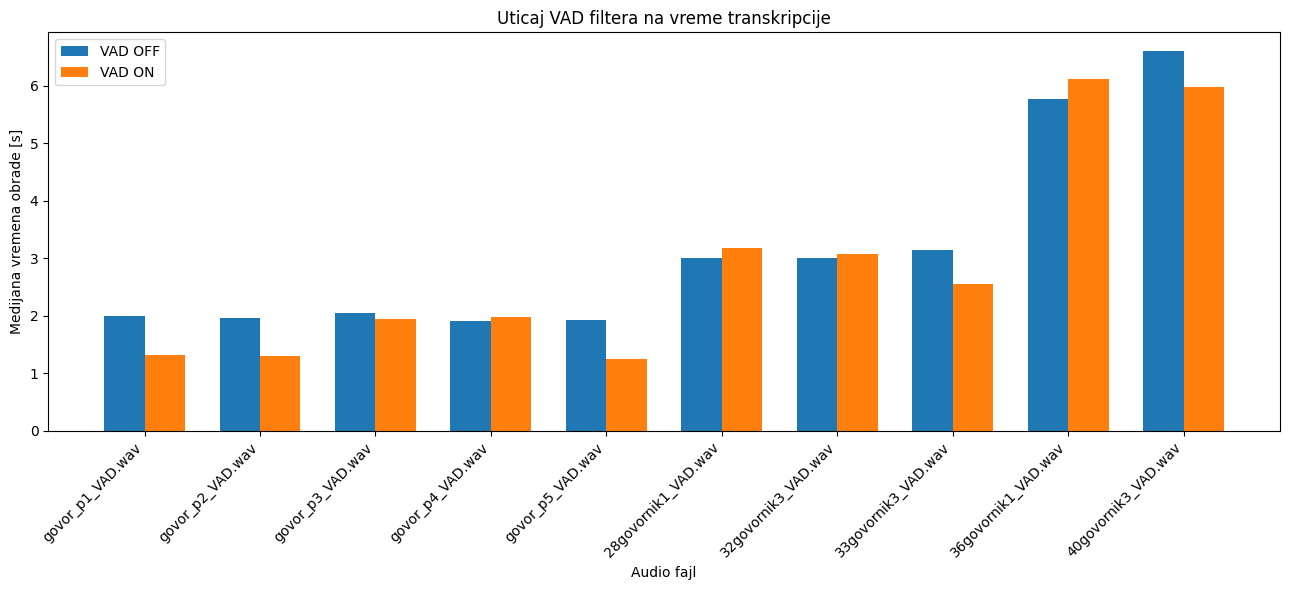

In [18]:
# ============================================================
# GRAFIK — VREME OBRADE PO FAJLU
# ============================================================

grafik = tabela_poredjenje.copy()

x = np.arange(len(grafik))
sirina = 0.35

plt.figure(figsize=(13, 6))

plt.bar(
    x - sirina / 2,
    grafik["Medijana vremena [s]_OFF"],
    sirina,
    label="VAD OFF"
)

plt.bar(
    x + sirina / 2,
    grafik["Medijana vremena [s]_ON"],
    sirina,
    label="VAD ON"
)

plt.xlabel("Audio fajl")
plt.ylabel("Medijana vremena obrade [s]")
plt.title("Uticaj VAD filtera na vreme transkripcije")
plt.xticks(x, grafik["Fajl"], rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

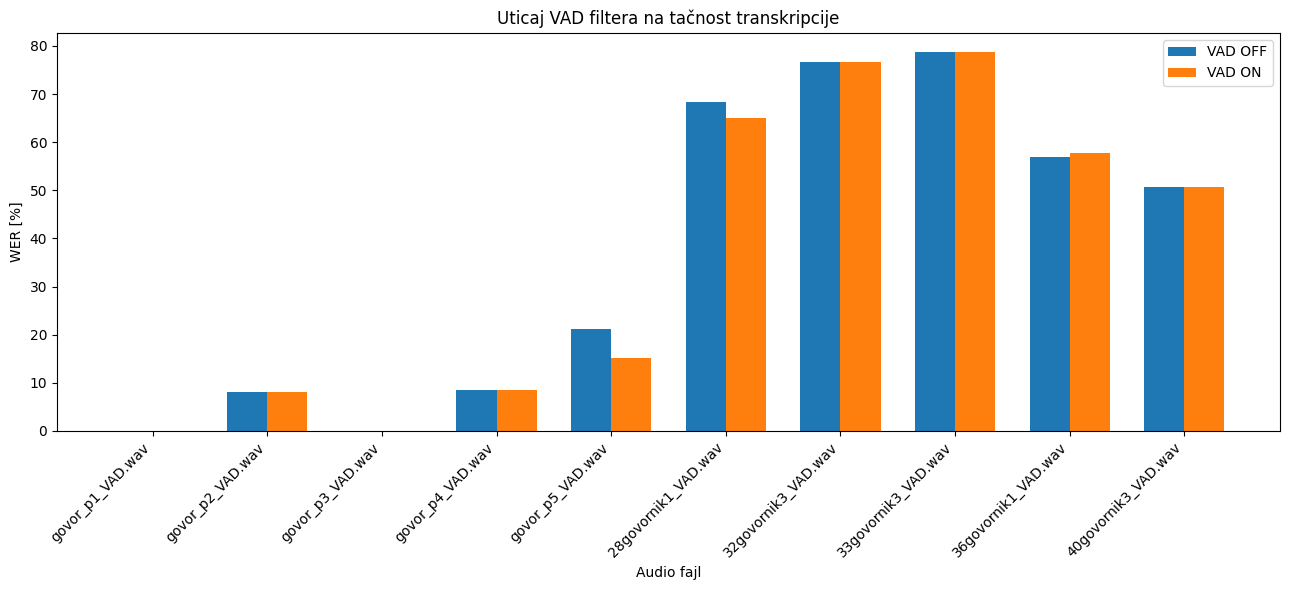

In [19]:
# ============================================================
# GRAFIK — WER VAD OFF VS VAD ON
# ============================================================

plt.figure(figsize=(13, 6))

plt.bar(
    x - sirina / 2,
    grafik["WER [%]_OFF"],
    sirina,
    label="VAD OFF"
)

plt.bar(
    x + sirina / 2,
    grafik["WER [%]_ON"],
    sirina,
    label="VAD ON"
)

plt.xlabel("Audio fajl")
plt.ylabel("WER [%]")
plt.title("Uticaj VAD filtera na tačnost transkripcije")
plt.xticks(x, grafik["Fajl"], rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

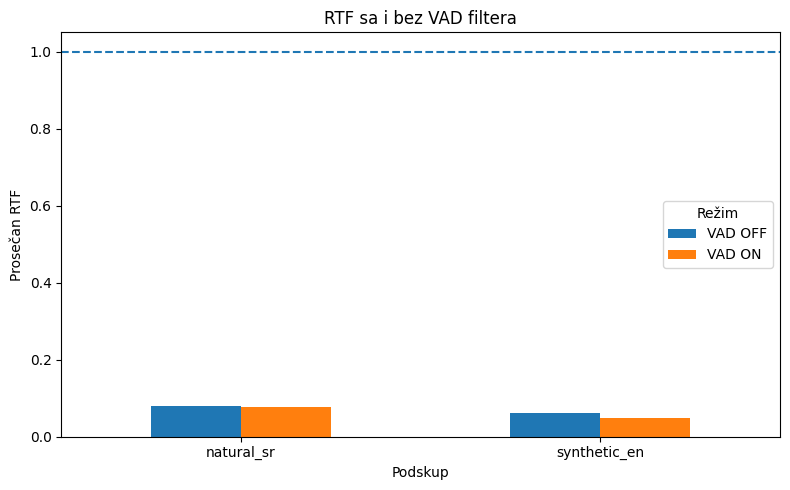

In [20]:
# ============================================================
# GRAFIK — PROSEČAN RTF PO PODSKUPU
# ============================================================

rtf_pivot = (
    rezime
    .pivot(
        index="Podskup",
        columns="Režim",
        values="Prosecan_RTF"
    )
)

rtf_pivot.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.axhline(1.0, linestyle="--")
plt.xlabel("Podskup")
plt.ylabel("Prosečan RTF")
plt.title("RTF sa i bez VAD filtera")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

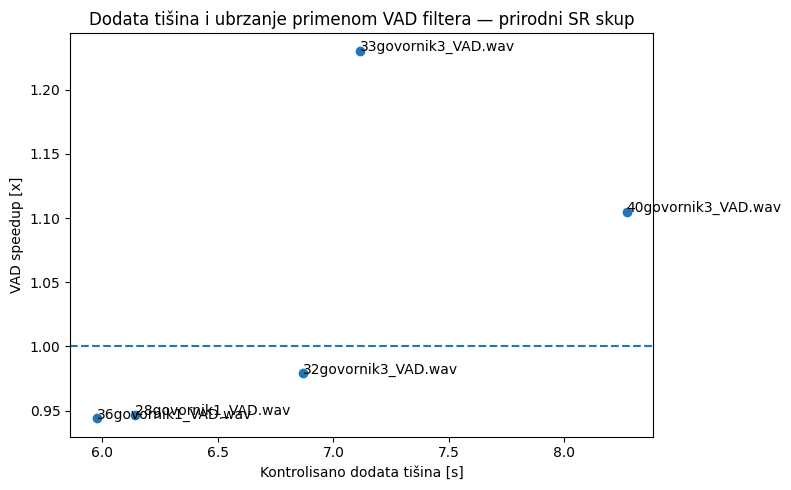

In [21]:
# ============================================================
# ODNOS KOLIČINE DODATE TIŠINE I UBRZANJA — SAMO SR
# ============================================================

sr_poredjenje = tabela_poredjenje[
    tabela_poredjenje["Podskup"] == "natural_sr"
].copy()

plt.figure(figsize=(8, 5))

plt.scatter(
    sr_poredjenje["Dodata tišina [s]_OFF"],
    sr_poredjenje["Ubrzanje VAD [x]"]
)

for _, red in sr_poredjenje.iterrows():
    plt.annotate(
        red["Fajl"],
        (
            red["Dodata tišina [s]_OFF"],
            red["Ubrzanje VAD [x]"]
        )
    )

plt.axhline(1.0, linestyle="--")
plt.xlabel("Kontrolisano dodata tišina [s]")
plt.ylabel("VAD speedup [x]")
plt.title("Dodata tišina i ubrzanje primenom VAD filtera — prirodni SR skup")
plt.tight_layout()
plt.show()

In [22]:
# ============================================================
# AUTOMATSKI ZAVRŠNI REZIME
# ============================================================

print("=" * 100)
print("ZAVRŠNI REZIME — UTICAJ VAD FILTERA")
print("=" * 100)

print(f"Model: Faster-Whisper {MODEL_SIZE} {COMPUTE_TYPE.upper()} / {DEVICE.upper()}")
print(f"Ukupno VAD fajlova: {len(test_set)}")
print(f"Broj sintetičkih EN fajlova: {sum(x['podskup'] == 'synthetic_en' for x in test_set)}")
print(f"Broj prirodnih SR fajlova: {sum(x['podskup'] == 'natural_sr' for x in test_set)}")
print(f"Broj ponavljanja vremena po režimu: {BROJ_PONAVLJANJA}")


for _, red in tabela_agregatno.iterrows():

    print("\n" + "-" * 80)
    print(f"PODSKUP: {red['Podskup']}")
    print("-" * 80)

    print(
        f"Vreme VAD OFF: {red['Prosečno vreme OFF [s]']:.3f} s"
    )

    print(
        f"Vreme VAD ON:  {red['Prosečno vreme ON [s]']:.3f} s"
    )

    print(
        f"VAD speedup:   {red['VAD speedup [x]']:.3f}x"
    )

    print(
        f"Smanjenje vremena: {red['Smanjenje vremena [%]']:.2f}%"
    )

    print(
        f"RTF OFF / ON: {red['Prosečan RTF OFF']:.4f} / "
        f"{red['Prosečan RTF ON']:.4f}"
    )

    print(
        f"WER OFF / ON: {red['Prosečan WER OFF [%]']:.2f}% / "
        f"{red['Prosečan WER ON [%]']:.2f}%"
    )

    print(
        f"Promena WER-a: {red['Promena WER [pp]']:+.2f} pp"
    )

ZAVRŠNI REZIME — UTICAJ VAD FILTERA
Model: Faster-Whisper base INT8 / CPU
Ukupno VAD fajlova: 10
Broj sintetičkih EN fajlova: 5
Broj prirodnih SR fajlova: 5
Broj ponavljanja vremena po režimu: 3

--------------------------------------------------------------------------------
PODSKUP: synthetic_en
--------------------------------------------------------------------------------
Vreme VAD OFF: 1.968 s
Vreme VAD ON:  1.557 s
VAD speedup:   1.263x
Smanjenje vremena: 20.85%
RTF OFF / ON: 0.0610 / 0.0480
WER OFF / ON: 7.58% / 6.37%
Promena WER-a: -1.21 pp

--------------------------------------------------------------------------------
PODSKUP: natural_sr
--------------------------------------------------------------------------------
Vreme VAD OFF: 4.302 s
Vreme VAD ON:  4.175 s
VAD speedup:   1.031x
Smanjenje vremena: 2.96%
RTF OFF / ON: 0.0800 / 0.0780
WER OFF / ON: 66.28% / 65.80%
Promena WER-a: -0.48 pp


In [23]:
# ============================================================
# ČUVANJE REZULTATA
# ============================================================

tabela_provera.to_csv(
    REZULTATI_DIR / "06_vad_provera_audio_fajlova.csv",
    index=False,
    encoding="utf-8-sig"
)

df.to_csv(
    REZULTATI_DIR / "06_vad_svi_rezultati.csv",
    index=False,
    encoding="utf-8-sig"
)

rezime.to_csv(
    REZULTATI_DIR / "06_vad_rezime.csv",
    index=False,
    encoding="utf-8-sig"
)

tabela_corpus.to_csv(
    REZULTATI_DIR / "06_vad_corpus_wer.csv",
    index=False,
    encoding="utf-8-sig"
)

tabela_poredjenje.to_csv(
    REZULTATI_DIR / "06_vad_off_vs_on_po_fajlu.csv",
    index=False,
    encoding="utf-8-sig"
)

tabela_agregatno.to_csv(
    REZULTATI_DIR / "06_vad_agregatni_rezultati.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Rezultati su sačuvani u:")
print(REZULTATI_DIR)

Rezultati su sačuvani u:
D:\0000000000MasterRad\aleksandar_jovanović_Faster-Whisper&CTranslate2_2026\Projekat2ASR\rezultati\06_uticaj_vad_filtera


## Zaključak eksperimenta

Eksperiment pokazuje da Voice Activity Detection može smanjiti vreme Faster-Whisper transkripcije audio zapisa koji sadrže periode bez govora, ali veličina poboljšanja zavisi od karakteristika konkretnog audio zapisa.

Najizraženiji efekat zabeležen je na sintetičkom engleskom podskupu, gde je VAD smanjio prosečno vreme obrade sa **1,968 s na 1,557 s**, odnosno za **20,85%**, uz ubrzanje od **1,263×**. Prosečan RTF smanjen je sa **0,061 na 0,048**.

Kod prirodnog srpskog podskupa poboljšanje performansi bilo je znatno manje. Prosečno vreme smanjeno je sa **4,302 s na 4,175 s**, odnosno za **2,96%**, uz ubrzanje od **1,031×**. Na pojedinim srpskim snimcima VAD je čak blago povećao vreme obrade, što pokazuje da trošak detekcije govora može poništiti korist od uklanjanja tišine.

Sa aspekta tačnosti, uključivanje VAD-a nije dovelo do sistematskog pogoršanja transkripcije. Prosečan WER promenjen je sa **7,58% na 6,37%** kod engleskog i sa **66,28% na 65,80%** kod srpskog podskupa. Corpus WER pokazuje sličnu sliku: **7,14% → 6,04%** za engleski i **62,47% → 62,25%** za srpski.

Rezultati zato ukazuju da je VAD prvenstveno **optimizacija zavisna od strukture audio zapisa**, a ne mehanizam koji garantuje ubrzanje svakog pojedinačnog snimka. Najveća korist može se očekivati kada audio sadrži dovoljno duge periode bez govora da ušteda obrade nadmaši dodatni trošak samog VAD algoritma.

Zbog ograničenog broja od pet snimaka po podskupu, rezultate treba posmatrati kao eksperimentalni pokazatelj ponašanja VAD-a u kontrolisanim uslovima, a ne kao univerzalnu procenu njegovog efekta na engleski i srpski govor.
